In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("cleaned_dataset_sample.csv")

print(df.head())
print(df.columns)

  symbol        date    open     high     low   close   volume
0    vno  2016-12-19  103.89  104.790  103.51  103.91  1123277
1    nbl  2014-09-17   71.50   71.630   70.58   71.17  1955639
2    flr  2016-01-04   46.53   47.760   46.26   47.71  1645312
3    whr  2015-11-12  157.16  157.160  155.10  155.50   800809
4    dri  2016-01-06   62.83   63.605   62.56   62.92  2001050
Index(['symbol', 'date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')


In [3]:
X = df[['open', 'high', 'low', 'close', 'volume']]

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

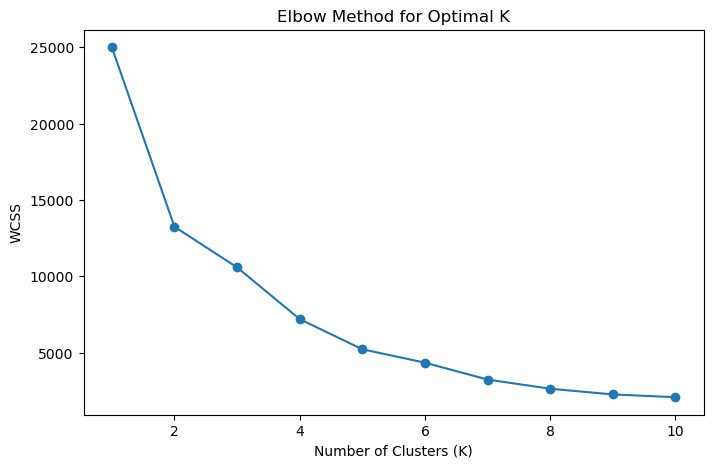

In [5]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Cluster labels add karo
df['Cluster'] = clusters

print(df[['open', 'close', 'volume', 'Cluster']].head())

     open   close   volume  Cluster
0  103.89  103.91  1123277        0
1   71.50   71.17  1955639        0
2   46.53   47.71  1645312        0
3  157.16  155.50   800809        0
4   62.83   62.92  2001050        0


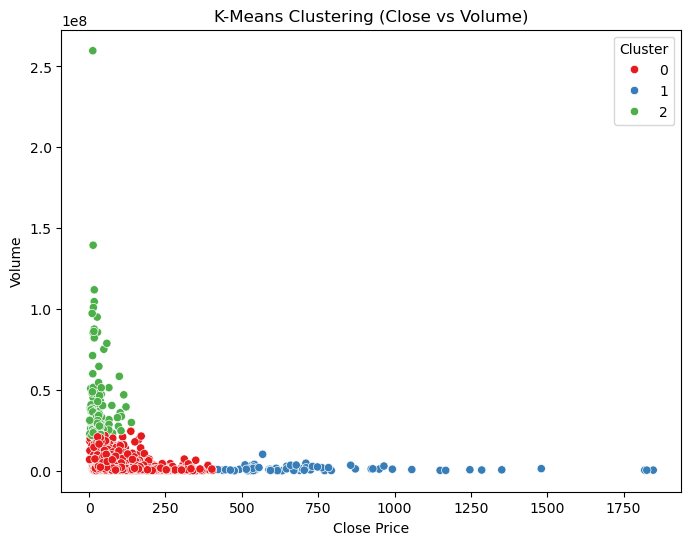

In [7]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['close'],
    y=df['volume'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("K-Means Clustering (Close vs Volume)")
plt.xlabel("Close Price")
plt.ylabel("Volume")
plt.show()